# simclr_no_projector

**必須重新訓練**  
圖片 → 🧠 Backbone(512維) → **直接**算 NT-Xent → kNN → Linear Probe

*重新做一個不同版本的 SimCLR，再拿去考試*

## step1:Import + GPU

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import resnet18

import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## step2:SimCLR Augmentation + CIFAR-10

In [2]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)


class SimCLRTransform:
    def __init__(self):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(
                32,
                scale=(0.2, 1.0)
            ),

            transforms.RandomHorizontalFlip(),

            transforms.RandomApply([
                transforms.ColorJitter(
                    brightness=0.4,
                    contrast=0.4,
                    saturation=0.4,
                    hue=0.1
                )
            ], p=0.8),

            transforms.RandomGrayscale(p=0.2),

            transforms.ToTensor(),

            transforms.Normalize(
                CIFAR10_MEAN,
                CIFAR10_STD
            )
        ])

    def __call__(self, image):
        view1 = self.transform(image)
        view2 = self.transform(image)

        return view1, view2


train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=SimCLRTransform()
)

batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

print("SSL Train:", len(train_dataset))

c:\Users\user\anaconda3\envs\summer\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


SSL Train: 50000


## step3:kNN / Linear Probing Dataset

In [3]:
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

eval_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=eval_transform
)

eval_test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=eval_transform
)

eval_train_loader = DataLoader(
    eval_train_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

eval_test_loader = DataLoader(
    eval_test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

print("Evaluation Train:", len(eval_train_dataset))
print("Evaluation Test:", len(eval_test_dataset))

Evaluation Train: 50000
Evaluation Test: 10000


## step4:No-Projector ResNet-18

In [4]:
class NoProjectorSimCLR(nn.Module):

    def __init__(self):
        super().__init__()

        self.backbone = resnet18(weights=None)

        # CIFAR-10 modification
        self.backbone.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.backbone.maxpool = nn.Identity()

        # 移除 classification head
        self.backbone.fc = nn.Identity()

    def forward(self, x):

        # 直接輸出 512-d representation
        h = self.backbone(x)

        return h

## step5:NT-Xent Loss

In [5]:
def nt_xent_loss(z1, z2, temperature=0.5):

    N = z1.size(0)

    # [N, 512] + [N, 512]
    # → [2N, 512]
    z = torch.cat([z1, z2], dim=0)

    # Normalize
    z = F.normalize(z, dim=1)

    # Pairwise cosine similarity
    similarity = torch.matmul(z, z.T) / temperature

    # 排除自己
    mask = torch.eye(
        2 * N,
        dtype=torch.bool,
        device=z.device
    )

    similarity.masked_fill_(
        mask,
        -float("inf")
    )

    # Positive pair index
    labels = torch.arange(
        2 * N,
        device=z.device
    )

    labels = (labels + N) % (2 * N)

    loss = F.cross_entropy(
        similarity,
        labels
    )

    return loss

## step6:kNN Monitor

In [6]:
@torch.no_grad()
def knn_monitor(
    model,
    train_loader,
    test_loader,
    device,
    k=20
):

    model.eval()

    feature_bank = []
    label_bank = []

    # 建立 training feature bank
    for images, labels in train_loader:

        images = images.to(device)

        features = model(images)

        features = F.normalize(
            features,
            dim=1
        )

        feature_bank.append(features)
        label_bank.append(labels)

    feature_bank = torch.cat(
        feature_bank,
        dim=0
    )

    label_bank = torch.cat(
        label_bank,
        dim=0
    ).to(device)

    correct = 0
    total = 0

    # Test
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        features = model(images)

        features = F.normalize(
            features,
            dim=1
        )

        similarity = torch.mm(
            features,
            feature_bank.T
        )

        _, indices = similarity.topk(
            k=k,
            dim=1
        )

        neighbor_labels = label_bank[indices]

        predictions = torch.mode(
            neighbor_labels,
            dim=1
        ).values

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    accuracy = 100.0 * correct / total

    model.train()

    return accuracy

## step7:正式 SSL Training 200 Epochs

In [7]:
# =============================
# Experiment 6
# SimCLR WITHOUT Projector
# =============================

num_epochs = 200

temperature = 0.5

learning_rate = 3e-4
weight_decay = 1e-6

knn_interval = 5
k = 20


# 全新模型
model = NoProjectorSimCLR().to(device)


optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)


loss_history = []
knn_epochs = []
knn_history = []


training_start = time.time()


for epoch in range(1, num_epochs + 1):

    model.train()

    total_loss = 0.0

    epoch_start = time.time()


    for (x1, x2), _ in train_loader:

        x1 = x1.to(device)
        x2 = x2.to(device)

        optimizer.zero_grad()

        # Backbone output = 512-d
        z1 = model(x1)
        z2 = model(x2)

        loss = nt_xent_loss(
            z1,
            z2,
            temperature=temperature
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()


    avg_loss = total_loss / len(train_loader)

    loss_history.append(avg_loss)


    epoch_time = time.time() - epoch_start


    print(
        f"Epoch [{epoch:3d}/{num_epochs}] "
        f"| Loss: {avg_loss:.4f} "
        f"| Time: {epoch_time:.1f}s",
        end=""
    )


    # =============================
    # kNN every 5 epochs
    # =============================

    if epoch % knn_interval == 0:

        knn_start = time.time()

        knn_acc = knn_monitor(
            model,
            eval_train_loader,
            eval_test_loader,
            device,
            k=k
        )

        knn_time = time.time() - knn_start


        knn_epochs.append(epoch)
        knn_history.append(knn_acc)


        print(
            f" | kNN Accuracy: {knn_acc:.2f}% "
            f"| kNN Time: {knn_time:.1f}s"
        )


        # checkpoint
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss_history": loss_history,
                "knn_epochs": knn_epochs,
                "knn_history": knn_history
            },
            "simclr_no_projector_checkpoint.pth"
        )

    else:
        print()


# =============================
# Final Save
# =============================

torch.save(
    model.state_dict(),
    "simclr_no_projector_final.pth"
)


total_time = time.time() - training_start


print("\n===== No Projector SSL Finished =====")

print(
    f"Total Training Time: "
    f"{total_time / 3600:.2f} hours"
)

print(
    f"Final Loss: "
    f"{loss_history[-1]:.4f}"
)

print(
    f"Final kNN Accuracy: "
    f"{knn_history[-1]:.2f}%"
)

Epoch [  1/200] | Loss: 5.5286 | Time: 73.1s
Epoch [  2/200] | Loss: 5.3082 | Time: 72.8s
Epoch [  3/200] | Loss: 5.2139 | Time: 72.3s
Epoch [  4/200] | Loss: 5.1454 | Time: 72.4s
Epoch [  5/200] | Loss: 5.1001 | Time: 72.3s | kNN Accuracy: 48.67% | kNN Time: 9.3s
Epoch [  6/200] | Loss: 5.0564 | Time: 73.4s
Epoch [  7/200] | Loss: 5.0236 | Time: 73.0s
Epoch [  8/200] | Loss: 4.9990 | Time: 72.7s
Epoch [  9/200] | Loss: 4.9786 | Time: 72.5s
Epoch [ 10/200] | Loss: 4.9567 | Time: 72.6s | kNN Accuracy: 58.35% | kNN Time: 9.2s
Epoch [ 11/200] | Loss: 4.9424 | Time: 72.7s
Epoch [ 12/200] | Loss: 4.9263 | Time: 72.8s
Epoch [ 13/200] | Loss: 4.9146 | Time: 72.7s
Epoch [ 14/200] | Loss: 4.9014 | Time: 72.7s
Epoch [ 15/200] | Loss: 4.8907 | Time: 72.9s | kNN Accuracy: 64.22% | kNN Time: 9.2s
Epoch [ 16/200] | Loss: 4.8798 | Time: 73.0s
Epoch [ 17/200] | Loss: 4.8739 | Time: 73.0s
Epoch [ 18/200] | Loss: 4.8652 | Time: 72.6s
Epoch [ 19/200] | Loss: 4.8556 | Time: 72.7s
Epoch [ 20/200] | Loss: 4

## step8:畫 Loss + kNN Curve

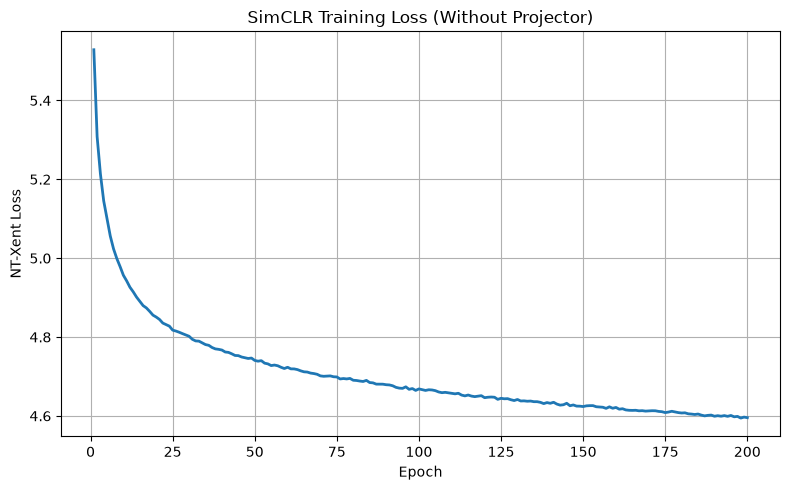

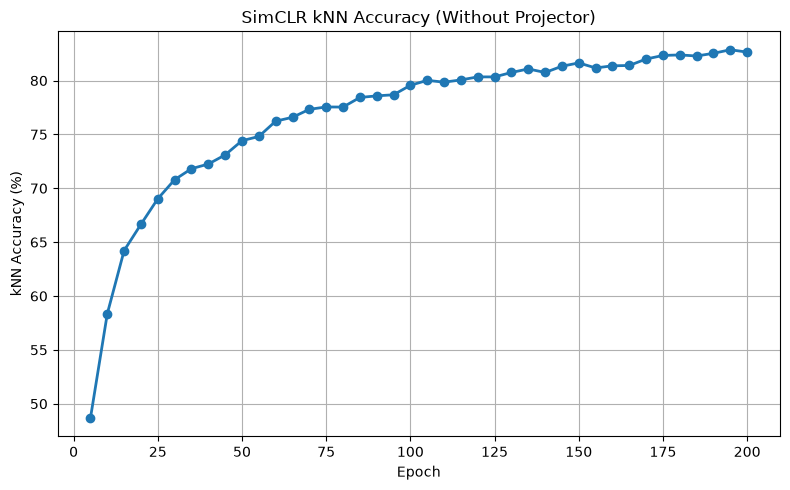

In [8]:
# =============================
# Loss Curve
# =============================

epochs = range(
    1,
    len(loss_history) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    loss_history,
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("NT-Xent Loss")

plt.title(
    "SimCLR Training Loss "
    "(Without Projector)"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "no_projector_loss_curve.png",
    dpi=300
)

plt.show()


# =============================
# kNN Curve
# =============================

plt.figure(figsize=(8, 5))

plt.plot(
    knn_epochs,
    knn_history,
    marker="o",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("kNN Accuracy (%)")

plt.title(
    "SimCLR kNN Accuracy "
    "(Without Projector)"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "no_projector_knn_curve.png",
    dpi=300
)

plt.show()

## step9:Freeze Backbone，準備 Linear Probing

In [9]:
# Freeze backbone

for param in model.parameters():
    param.requires_grad = False

model.eval()


print(
    "Trainable backbone parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)

Trainable backbone parameters: 0


## step10:Linear Probe Dataset

In [10]:
linear_train_loader = DataLoader(
    eval_train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=0
)

linear_test_loader = DataLoader(
    eval_test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

## step11:Linear Classifier

In [11]:
linear_classifier = nn.Linear(
    512,
    10
).to(device)


criterion = nn.CrossEntropyLoss()


linear_optimizer = optim.Adam(
    linear_classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-6
)


print(linear_classifier)

Linear(in_features=512, out_features=10, bias=True)


## step12:Linear Probing 100 Epochs

In [12]:
linear_epochs = 100

linear_loss_history = []
linear_test_accuracy = []


linear_start = time.time()


for epoch in range(1, linear_epochs + 1):

    # =====================
    # Train
    # =====================

    linear_classifier.train()
    model.eval()

    total_loss = 0.0


    for images, labels in linear_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        linear_optimizer.zero_grad()


        with torch.no_grad():

            features = model(images)


        outputs = linear_classifier(
            features
        )


        loss = criterion(
            outputs,
            labels
        )


        loss.backward()

        linear_optimizer.step()


        total_loss += loss.item()


    avg_loss = (
        total_loss /
        len(linear_train_loader)
    )


    linear_loss_history.append(
        avg_loss
    )


    # =====================
    # Test
    # =====================

    linear_classifier.eval()

    correct = 0
    total = 0


    with torch.no_grad():

        for images, labels in linear_test_loader:

            images = images.to(device)
            labels = labels.to(device)

            features = model(images)

            outputs = linear_classifier(
                features
            )

            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)


    test_acc = (
        100.0 *
        correct /
        total
    )


    linear_test_accuracy.append(
        test_acc
    )


    print(
        f"Epoch [{epoch:3d}/{linear_epochs}] "
        f"| Loss: {avg_loss:.4f} "
        f"| Test Accuracy: {test_acc:.2f}%"
    )


linear_elapsed = (
    time.time() -
    linear_start
)


print(
    "\n===== No Projector "
    "Linear Probing Finished ====="
)

print(
    f"Training Time: "
    f"{linear_elapsed / 60:.2f} minutes"
)

print(
    f"Final Test Accuracy: "
    f"{linear_test_accuracy[-1]:.2f}%"
)

print(
    f"Best Test Accuracy: "
    f"{max(linear_test_accuracy):.2f}%"
)

Epoch [  1/100] | Loss: 1.1562 | Test Accuracy: 81.78%
Epoch [  2/100] | Loss: 0.6187 | Test Accuracy: 82.54%
Epoch [  3/100] | Loss: 0.5351 | Test Accuracy: 82.82%
Epoch [  4/100] | Loss: 0.5031 | Test Accuracy: 82.99%
Epoch [  5/100] | Loss: 0.4851 | Test Accuracy: 83.14%
Epoch [  6/100] | Loss: 0.4747 | Test Accuracy: 83.30%
Epoch [  7/100] | Loss: 0.4674 | Test Accuracy: 83.43%
Epoch [  8/100] | Loss: 0.4623 | Test Accuracy: 83.50%
Epoch [  9/100] | Loss: 0.4577 | Test Accuracy: 83.49%
Epoch [ 10/100] | Loss: 0.4548 | Test Accuracy: 83.54%
Epoch [ 11/100] | Loss: 0.4519 | Test Accuracy: 83.59%
Epoch [ 12/100] | Loss: 0.4496 | Test Accuracy: 83.64%
Epoch [ 13/100] | Loss: 0.4478 | Test Accuracy: 83.67%
Epoch [ 14/100] | Loss: 0.4465 | Test Accuracy: 83.61%
Epoch [ 15/100] | Loss: 0.4450 | Test Accuracy: 83.71%
Epoch [ 16/100] | Loss: 0.4431 | Test Accuracy: 83.71%
Epoch [ 17/100] | Loss: 0.4428 | Test Accuracy: 83.65%
Epoch [ 18/100] | Loss: 0.4411 | Test Accuracy: 83.59%
Epoch [ 19